In [195]:
# Install the tsfm library
! pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.22"

  Cloning https://github.com/ibm-granite/granite-tsfm.git (to revision v0.2.22) to /private/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/pip-install-obdz0ci5/granite-tsfm_4662d7873606461ba836c3600a4c79fe
  Running command git clone --filter=blob:none --quiet https://github.com/ibm-granite/granite-tsfm.git /private/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/pip-install-obdz0ci5/granite-tsfm_4662d7873606461ba836c3600a4c79fe
  Running command git checkout -q 216850d0cb073e31689049c1334f701fe11bc2c3
  Resolved https://github.com/ibm-granite/granite-tsfm.git to commit 216850d0cb073e31689049c1334f701fe11bc2c3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [196]:
import math
import os

import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, get_cosine_schedule_with_warmup
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_selection import mutual_info_regression

from tsfm_public import (
    TimeSeriesPreprocessor,
    TrackingCallback,
)
import tempfile
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.visualization import plot_predictions

In [197]:
# Reduced context length for slowly-changing variables like coolant temperature
# Original: 512 timesteps (after 5x downsampling = 2560 seconds = ~43 minutes)
# New: 256 timesteps (after 5x downsampling = 1280 seconds = ~21 minutes)
context_length = 512
forecast_length = 96

TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
revision = "main"
OUT_DIR = "ttm-finetune"

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [198]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata" 
time_col = 'ENGINE_RUN_TINE ()'

df_list = []
for file in os.listdir(path):
  if file.endswith('.csv'):
    df = pd.read_csv(f'{path}/{file}', index_col=False)
    df['drive_id'] = file
    df_list.append(df)

print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


129 files loaded out of 129


In [199]:
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
  """
  Compute std of each std-computable column (numeric only)
  """
  if exclude_cols is None:
        exclude_cols = []
    
  numeric_cols = df.select_dtypes(include=[np.number]).columns
  cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
  std_df = df[cols_to_check].std()
  zero_variance_cols = std_df[std_df == 0].index.tolist()
  
  print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
  if len(zero_variance_cols) > 0:
      df = df.drop(columns=zero_variance_cols)
  
  return df

In [200]:
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, id_cols: list[str] = None) -> pd.DataFrame:
  """
  Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
  This preserves the overall statistics while removing duplicate entries.
  
  Note: The time column itself is not averaged (it becomes the group key).
  Only numeric columns are averaged when multiple rows share the same timestamp.
  """
  if id_cols is None:
        id_cols = []
    
  
  existing_id_cols = [col for col in id_cols if col in df.columns]
  
  group_cols = [time_col] + existing_id_cols
  
  agg_dict = {}
  for col in df.columns:
      if col not in group_cols:
          if pd.api.types.is_numeric_dtype(df[col]):
              agg_dict[col] = 'mean'
          else:
              agg_dict[col] = 'first'
  
  df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
  return df_clean


In [201]:
def downsample(df, time_col, source_file_col, downsample_factor=2):
    result_dfs = []
    
    for source_file in df[source_file_col].unique():
        file_df = df[df[source_file_col] == source_file].copy()
        
        if len(file_df) < downsample_factor * 2:
            continue
        
        file_df = file_df.sort_values(time_col).reset_index(drop=True)
        
        # Simple decimation without pre-smoothing
        # The TTM model handles noise internally
        downsampled = file_df.iloc[::downsample_factor].copy()
        downsampled[time_col] = np.arange(len(downsampled)) * downsample_factor
        
        result_dfs.append(downsampled.reset_index(drop=True))
    
    return pd.concat(result_dfs, ignore_index=True)


In [202]:
def filter_long_drives(df, id_col='drive_id', min_length=608):
    """Keep only drives long enough for your context window"""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    
    print(f"Keeping {len(valid_drives)}/{df[id_col].nunique()} drives")
    print(f"Dropped {len(df) - df[df[id_col].isin(valid_drives)].shape[0]} timesteps")
    
    return df[df[id_col].isin(valid_drives)].reset_index(drop=True)

In [203]:
data = pd.concat(df_list, ignore_index=True)

# Clean up

print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")

data = mean_fill_missing_timestamps_and_remove_duplicates(data, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])
data = downsample(
    data,
    time_col='ENGINE_RUN_TINE ()',
    source_file_col='drive_id',
    downsample_factor=1
)

data = filter_long_drives(data)


data['speed_change'] = data.groupby('drive_id')['VEHICLE_SPEED ()'].diff()
data['rpm_change'] = data.groupby('drive_id')['ENGINE_RPM ()'].diff()


Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']
Keeping 59/129 drives
Dropped 28269 timesteps


In [ ]:
def add_cross_channel_features(data, target_columns):
    """
    Engineer features that capture cross-channel relationships.
    Add these as conditional columns.
    """
    # RPM-to-Speed ratio (gear indicator)
    if 'ENGINE_RPM ()' in data.columns and 'VEHICLE_SPEED ()' in data.columns:
        data['RPM_SPEED_RATIO'] = data['ENGINE_RPM ()'] / (data['VEHICLE_SPEED ()'] + 1)
    
    # Throttle-to-Load ratio (efficiency indicator)
    if 'THROTTLE ()' in data.columns and 'ENGINE_LOAD ()' in data.columns:
        data['THROTTLE_LOAD_RATIO'] = data['THROTTLE ()'] / (data['ENGINE_LOAD ()'] + 1)
    
    # Speed-based categories
    if 'VEHICLE_SPEED ()' in data.columns:
        data['IS_IDLE'] = (data['VEHICLE_SPEED ()'] < 5).astype(float)
        data['IS_HIGHWAY'] = (data['VEHICLE_SPEED ()'] > 60).astype(float)
    
    # RPM acceleration
    if 'ENGINE_RPM ()' in data.columns:
        data['RPM_ACCEL'] = data.groupby('drive_id')['ENGINE_RPM ()'].diff().fillna(0)
    
    return data

# Apply cross-channel features before preprocessing
target_columns = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]

data = add_cross_channel_features(data, target_columns)
print("Added cross-channel features")


In [204]:
from tsfm_public import get_datasets

target_columns = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]

split_params = {"train": 0.75, "test": 0.25}

column_specifiers = {
    "timestamp_column": time_col,
    "id_columns": ["drive_id"],
    "target_columns": target_columns,
    "conditional_columns": [col for col in data.columns if col not in target_columns + ["drive_id", time_col]],
}

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=forecast_length,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
    freq="s",
)

tsp = tsp.train(data)

train_dataset, valid_dataset, test_dataset = get_datasets(
    tsp,
    data,
    split_params,
    fewshot_fraction=1.0,
    fewshot_location="first",
    use_frequency_token=True,  # Enable frequency token for revision "180-60-ft-l1-r2.1"
)

def remove_zero_padded_samples(dataset):
    """Remove samples that are all zeros"""
    valid_indices = []
    for idx in range(len(dataset)):
        sample = dataset[idx]
        if 'past_values' in sample:
            if sample['past_values'].std() > 0.01:
                valid_indices.append(idx)
    
    print(f"Kept {len(valid_indices)}/{len(dataset)} valid samples")
    return torch.utils.data.Subset(dataset, valid_indices)

train_dataset = remove_zero_padded_samples(train_dataset)
valid_dataset = remove_zero_padded_samples(valid_dataset)
test_dataset = remove_zero_padded_samples(test_dataset)


Kept 7384/7384 valid samples
Kept 44/44 valid samples
Kept 6940/6955 valid samples


In [205]:
from tsfm_public import get_model

zeroshot_model = get_model(
    TTM_MODEL_PATH,
    context_length=context_length,
    prediction_length=forecast_length,
)


INFO:p-51643:t-8534990592:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-51643:t-8534990592:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.
INFO:p-51643:t-8534990592:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


In [206]:
temp_dir = tempfile.mkdtemp()
zeroshot_trainer = Trainer(
    model=zeroshot_model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=64,
    ),
)

In [207]:
zeroshot_trainer.evaluate(test_dataset)

/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.8157655596733093,
 'eval_model_preparation_time': 0.0032,
 'eval_runtime': 13.0263,
 'eval_samples_per_second': 532.77,
 'eval_steps_per_second': 8.368}

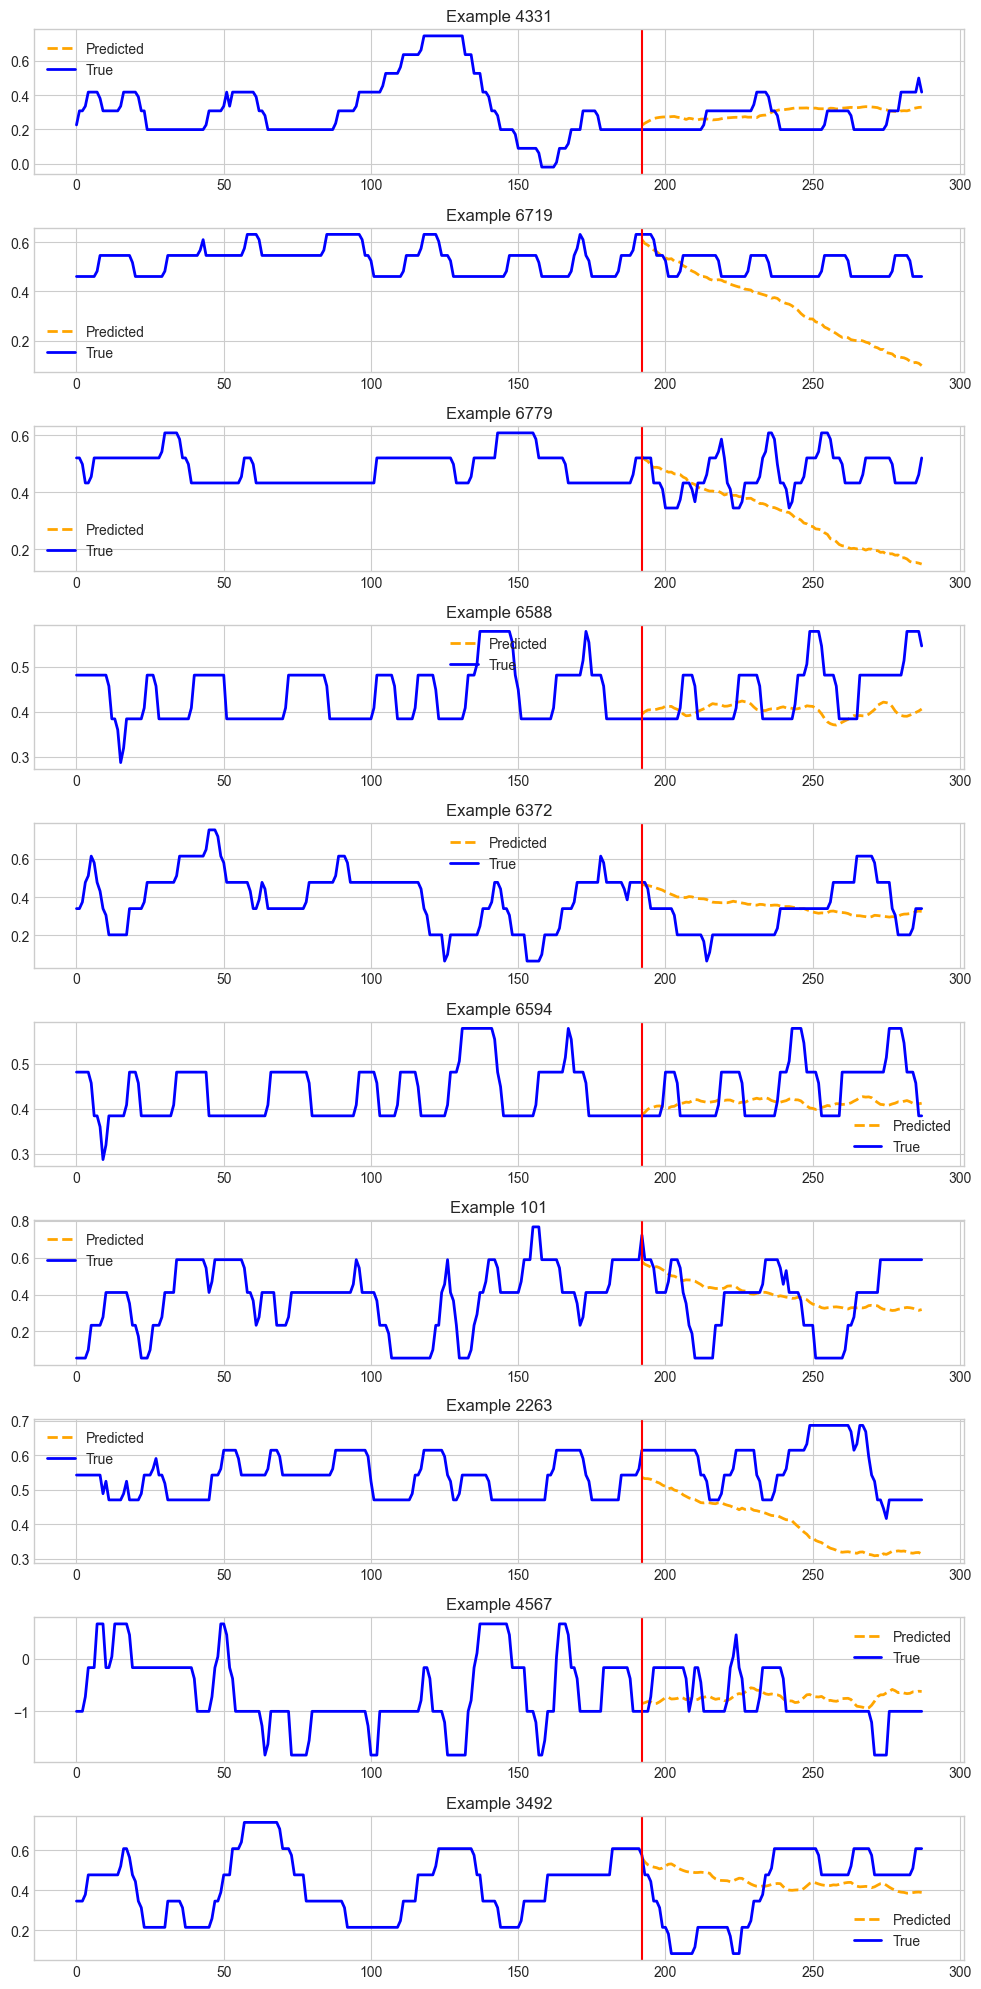

In [208]:
plot_predictions(
    model=zeroshot_trainer.model,
    dset=test_dataset,
    plot_prefix="test_zeroshot",
    channel=0,
)

In [270]:
finetune_forecast_model = get_model(
    TTM_MODEL_PATH,
    context_length=context_length,
    prediction_length=forecast_length,
)


INFO:p-51643:t-8534990592:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-51643:t-8534990592:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.
INFO:p-51643:t-8534990592:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


In [271]:
def unfreeze_cross_channel_layers(model):
    """
    Unfreeze layers responsible for cross-channel interactions.
    For TTM, these are typically the mixer layers.
    """
    unfrozen_count = 0
    
    for name, param in model.backbone.named_parameters():
        # Unfreeze layers with "mixer" or "channel" in name
        if any(keyword in name.lower() for keyword in ['mixer', 'channel', 'cross', 'attention']):
            param.requires_grad = True
            print(f"Unfroze: {name}")
            unfrozen_count += 1
    
    print(f"\nTotal cross-channel parameters unfrozen: {unfrozen_count}")
    return unfrozen_count


In [272]:
def unfreeze_last_n_layers(model, n_layers=None, percentage=0.3):
    """
    Unfreeze the last N layers of the backbone.
    
    Custom function to selectively unfreeze layers for fine-tuning.
    
    Args:
        model: Your TTM model with a .backbone attribute
        n_layers: Exact number of layers to unfreeze (overrides percentage)
        percentage: Fraction of layers to unfreeze (0.3 = last 30%)
    
    Returns:
        Number of layers unfrozen
    """
    # Get all backbone parameters
    backbone_params = list(model.backbone.named_parameters())
    total_layers = len(backbone_params)
    
    if n_layers is None:
        n_layers = int(total_layers * percentage)
    
    print(f"Total backbone parameters: {total_layers}")
    print(f"Unfreezing last {n_layers} layers ({n_layers/total_layers*100:.1f}%)")
    
    # Freeze all first
    for param in model.backbone.parameters():
        param.requires_grad = False
    
    # Unfreeze last N
    for name, param in backbone_params[-n_layers:]:
        param.requires_grad = True
        print(f"  Unfroze: {name}")
    
    return n_layers

In [273]:
def compute_clamp_ranges(dataset, use_percentiles=True):
    all_values = []
    for i in range(min(1000, len(dataset))):
        sample = dataset[i]
        all_values.append(sample['future_values'])
    
    all_values = torch.stack(all_values)
    clamp_range = {}
    n_features = all_values.shape[2]
    
    for feat_idx in range(n_features):
        feat_values = all_values[:, :, feat_idx].flatten()
        
        if use_percentiles:
            q01 = torch.quantile(feat_values, 0.01)
            q99 = torch.quantile(feat_values, 0.99)
            clamp_range[feat_idx] = (q01.item(), q99.item())
        else:
            mean = feat_values.mean().item()
            std = feat_values.std().item()
            clamp_range[feat_idx] = (mean - 2.5 * std, mean + 2.5 * std)
    
    return clamp_range

In [274]:
num_epochs = 100
batch_size = 64

learning_rate, finetune_forecast_model = optimal_lr_finder(
    finetune_forecast_model,
    train_dataset,
    batch_size=batch_size,
    device=device,
    enable_prefix_tuning=False,
)
print("OPTIMAL SUGGESTED LEARNING RATE =", learning_rate)

INFO:p-51643:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Running learning rate (LR) finder algorithm. If the suggested LR is very low, we suggest setting the LR manually.
INFO:p-51643:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Using CPU.
INFO:p-51643:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Suggested learning rate = 0.000298364724028334


OPTIMAL SUGGESTED LEARNING RATE = 0.000298364724028334


Training with MSE only (official TTM approach)...
Total backbone parameters: 98
Unfreezing last 19 layers (19.4%)
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.0.feature_mixer.mlp.fc2.bias
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.0.feature_mixer.gating_block.attn_layer.weight
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.0.feature_mixer.gating_block.attn_layer.bias
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.1.patch_mixer.norm.norm.weight
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.1.patch_mixer.norm.norm.bias
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.1.patch_mixer.mlp.fc1.weight
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.1.patch_mixer.mlp.fc1.bias
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.1.patch_mixer.mlp.fc2.weight
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.1.patch_mixer.mlp.fc2.bias
  Unfroze: encoder.mlp_mixer_encoder.mixers.2.mixer_layers.1.p

Epoch,Training Loss,Validation Loss
1,0.346100,0.315372
2,0.299700,0.303449
3,0.290900,0.294521
4,0.284200,0.293794
5,0.279900,0.289146
6,0.275700,0.286740
7,0.273000,0.290088
8,0.270400,0.292377
9,0.268600,0.288378
10,0.266400,0.285939


/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pin


=== Baseline MSE Results ===


/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.4170937240123749, 'eval_runtime': 12.3974, 'eval_samples_per_second': 559.795, 'eval_steps_per_second': 8.792, 'epoch': 70.0}

Generating prediction plots...


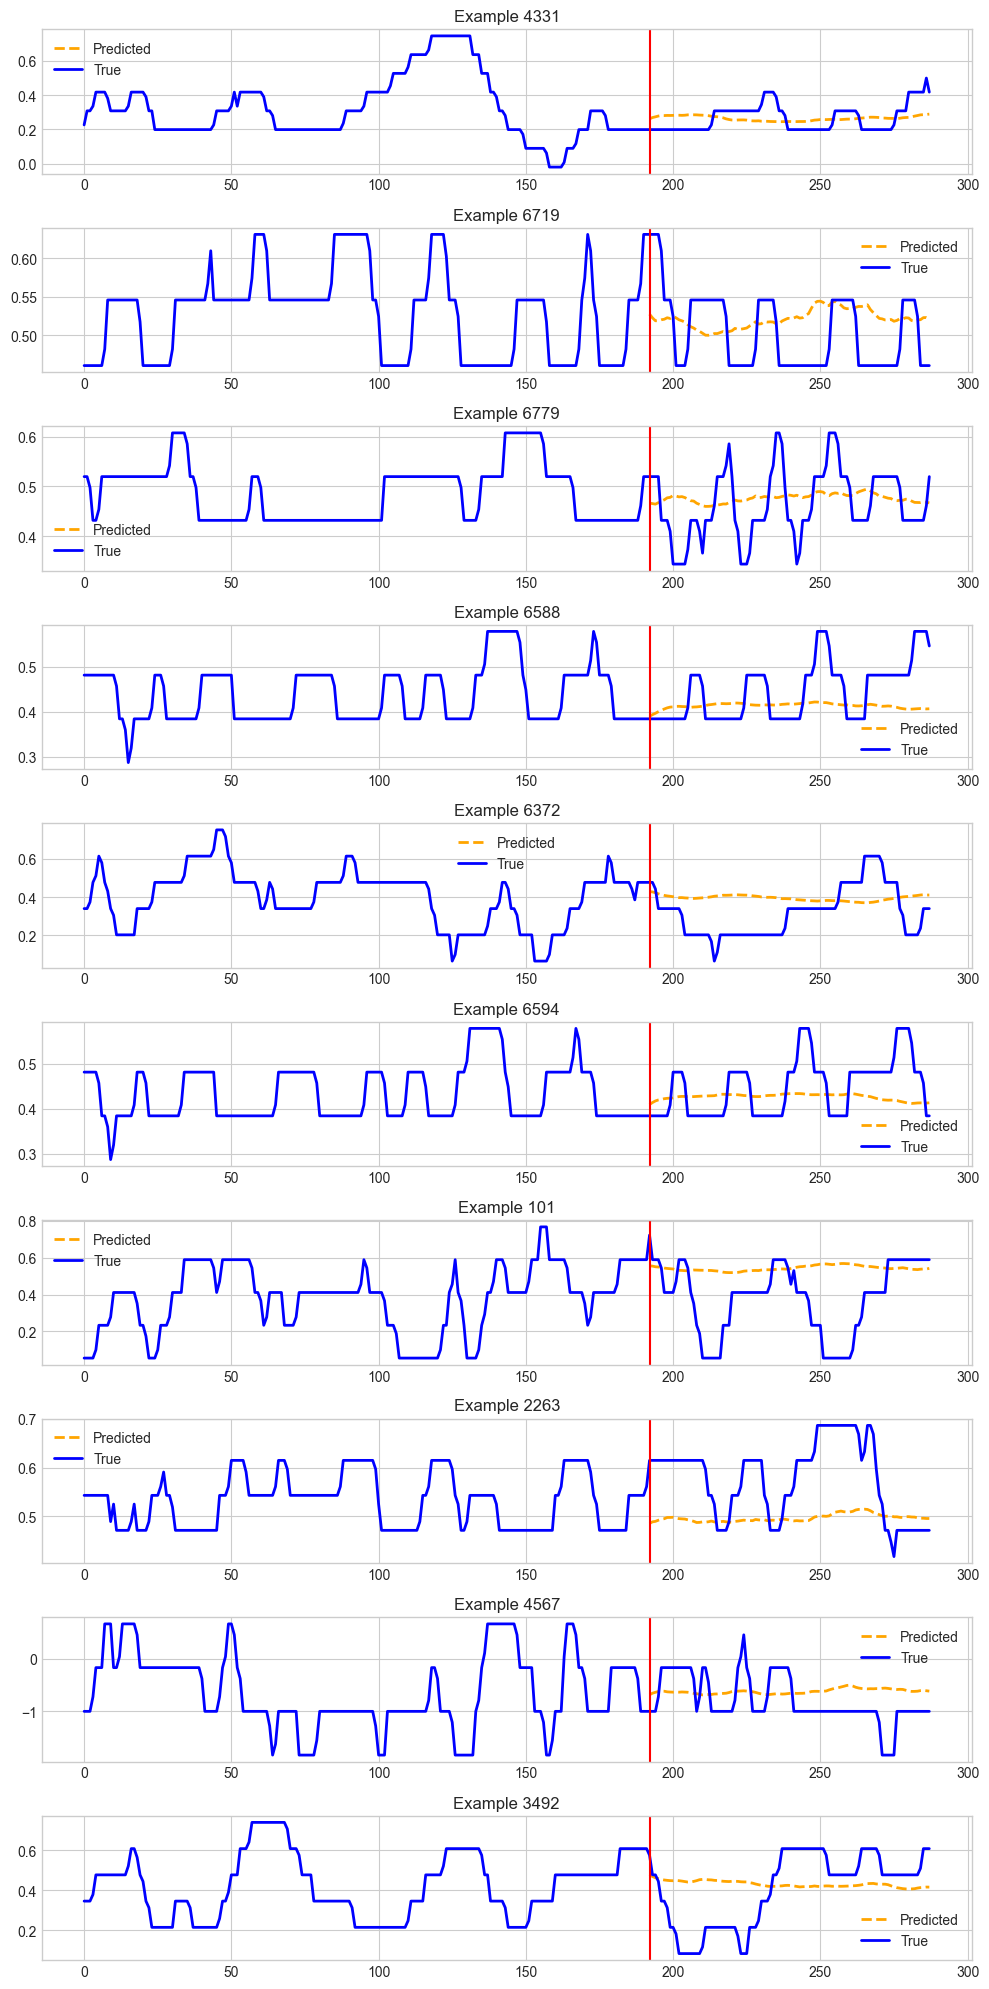

In [275]:
import torch
import torch.nn.functional as F
from transformers import Trainer, TrainingArguments
from accelerate import notebook_launcher

# Simple MSE-only trainer (like official TTM)
def train_baseline_mse():
    num_epochs = 70
    batch_size = 64
    
    training_args = TrainingArguments(
        output_dir="./ttm_baseline_mse",
        logging_dir="./logs",
        logging_strategy="epoch",
        logging_first_step=True,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        save_total_limit=3,
        weight_decay=0.05,
        warmup_ratio=0.05,
        report_to=["tensorboard"],  # Enable logging
    )
    
    # Freeze most of backbone
    unfreeze_last_n_layers(finetune_forecast_model, percentage=0.2)
    
    optimizer = AdamW(
        params=[p for p in finetune_forecast_model.parameters() if p.requires_grad],
        lr=learning_rate,
        weight_decay=0.05
    )
    
    num_training_steps = len(train_dataset) // batch_size * num_epochs
    num_warmup_steps = int(num_training_steps * 0.05)
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )
    
    trainer = Trainer(
        model=finetune_forecast_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        optimizers=(optimizer, scheduler),
    )
    
    print("Starting MSE-only baseline training...")
    trainer.train()
    
    trainer.save_model("./ttm_baseline_mse_final")
    
    print("\n=== Baseline MSE Results ===")
    test_results = trainer.evaluate(test_dataset)
    print(test_results)
    
    return trainer


# Run training
print("Training with MSE only (official TTM approach)...")
trainer = train_baseline_mse()

# After training, generate plots
print("\nGenerating prediction plots...")
plot_predictions(
    model=trainer.model,
    dset=test_dataset,
    plot_prefix="baseline_mse",
    channel=0,
    num_plots=10
)


In [ ]:
import torch
from transformers import Trainer, TrainingArguments
from accelerate import notebook_launcher


class FocalMultiObjectiveLoss(torch.nn.Module):
    def __init__(self, alpha_mse=0.8, alpha_deriv=1.2, alpha_deriv2=0.6,
                 alpha_spectral=0.3, alpha_continuity=1.0, alpha_range=0.4,
                 focal_gamma=2.0):
        super().__init__()
        self.alpha_mse = alpha_mse
        self.alpha_deriv = alpha_deriv
        self.alpha_deriv2 = alpha_deriv2
        self.alpha_spectral = alpha_spectral
        self.alpha_continuity = alpha_continuity
        self.alpha_range = alpha_range
        self.focal_gamma = focal_gamma
    
    def focal_loss(self, pred, target):
        """
        Focal loss: emphasizes hard-to-predict samples.
        Good for sharp transitions that standard MSE under-weights.
        """
        mse = (pred - target).pow(2)
        # Modulating factor: down-weight easy predictions
        focal_weight = (1 + mse).pow(self.focal_gamma)
        return (focal_weight * mse).mean()
    
    def forward(self, pred, target, context=None):
        # Use focal loss for point predictions
        mse_loss = self.focal_loss(pred, target)
        
        # Standard derivative losses
        pred_deriv = pred[:, 1:, :] - pred[:, :-1, :]
        target_deriv = target[:, 1:, :] - target[:, :-1, :]
        deriv_loss = self.focal_loss(pred_deriv, target_deriv)
        
        pred_deriv2 = pred_deriv[:, 1:, :] - pred_deriv[:, :-1, :]
        target_deriv2 = target_deriv[:, 1:, :] - target_deriv[:, :-1, :]
        deriv2_loss = self.focal_loss(pred_deriv2, target_deriv2)
        
        pred_fft = torch.fft.rfft(pred, dim=1)
        target_fft = torch.fft.rfft(target, dim=1)
        spectral_loss = F.mse_loss(torch.abs(pred_fft), torch.abs(target_fft))
        
        continuity_loss = 0.0
        if context is not None:
            continuity_loss = F.mse_loss(pred[:, 0, :], context[:, -1, :])
        
        range_loss = 0.0
        if context is not None:
            context_min = context.min(dim=1, keepdim=True)[0]
            context_max = context.max(dim=1, keepdim=True)[0]
            margin = 0.05 * (context_max - context_min)
            below_min = torch.relu(context_min - margin - pred)
            above_max = torch.relu(pred - context_max - margin)
            range_loss = (below_min.pow(2).mean() + above_max.pow(2).mean())
        
        total_loss = (
            self.alpha_mse * mse_loss +
            self.alpha_deriv * deriv_loss +
            self.alpha_deriv2 * deriv2_loss +
            self.alpha_spectral * spectral_loss +
            self.alpha_continuity * continuity_loss +
            self.alpha_range * range_loss
        )
        
        return total_loss


def train_function():
    num_epochs = 70
    batch_size = 64
    
    training_args = TrainingArguments(
        output_dir="./ttm_continuous",
        logging_dir="./logs",
        logging_strategy="epoch",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        save_total_limit=3,
        fp16=False,
    )
    
    optimizer = AdamW(
        params=finetune_forecast_model.parameters(), 
        lr=learning_rate, 
        weight_decay=0.05
    )
    
    num_training_steps = len(train_dataset) // batch_size * num_epochs
    num_warmup_steps = len(train_dataset) // batch_size * 2
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )
    
    clamp_range = compute_clamp_ranges(train_dataset, use_percentiles=True)
    
    custom_loss = FocalMultiObjectiveLoss(
        alpha_mse=0.8,          # Slightly reduce
        alpha_deriv=1.2,        # Significantly increase
        alpha_deriv2=0.6,       # Double from before
        alpha_spectral=0.3,     # Slight increase
        alpha_continuity=1.0,   # Keep (working perfectly)
        alpha_range=0.4,        # Reduce (too strict hurts dynamics)
        focal_gamma=2.0         # NEW: emphasize sharp transitions
    )
    
    trainer = SpectralTrainer(
        model=finetune_forecast_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        optimizers=(optimizer, scheduler),
        loss_fn=custom_loss,
        clamp_range=clamp_range,
    )
    
    trainer.train()
    trainer.save_model("./ttm_finetuned_final")
    print(trainer.evaluate(test_dataset))


notebook_launcher(train_function, args=(), num_processes=1)


Launching training on MPS.


TypeError: MultiObjectiveLoss.__init__() got an unexpected keyword argument 'focal_gamma'

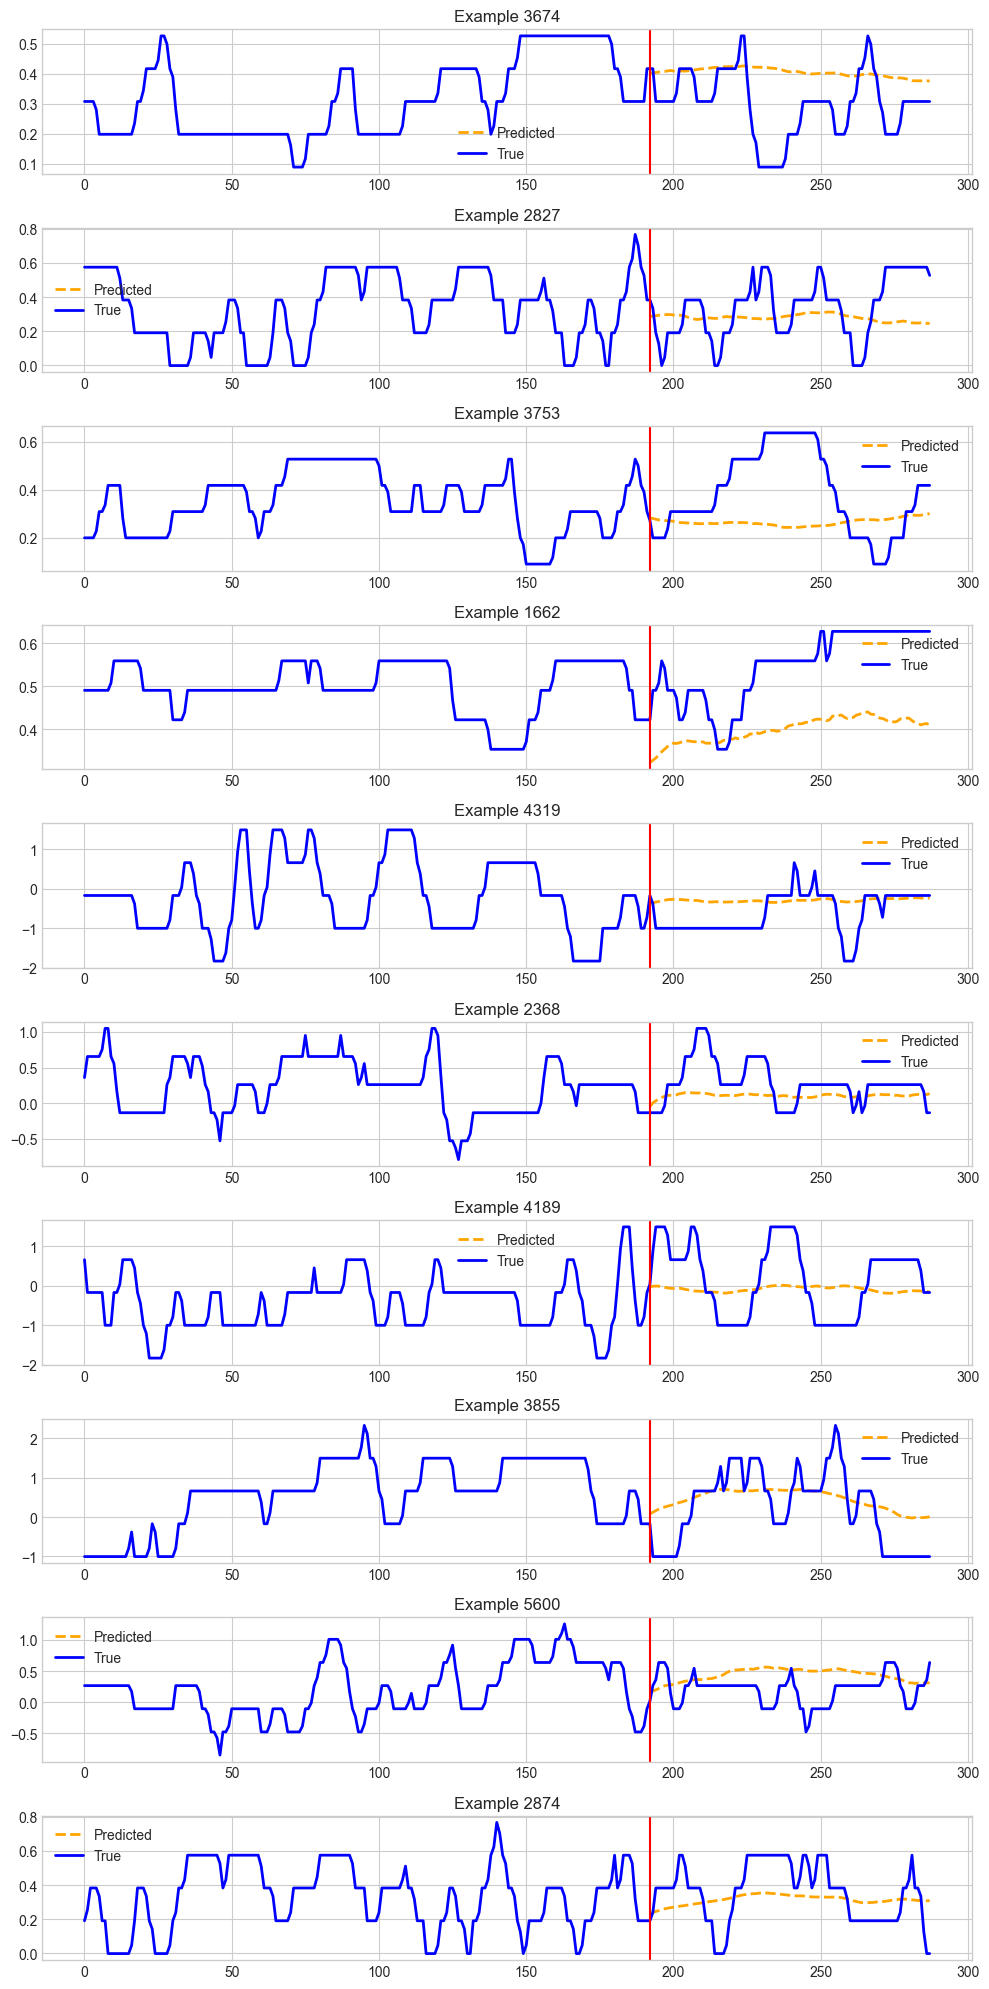

In [276]:
plot_predictions(
    model=finetune_forecast_model,
    dset=train_dataset,
    plot_prefix="test_finetune",
    channel=0,
    num_plots=10
)

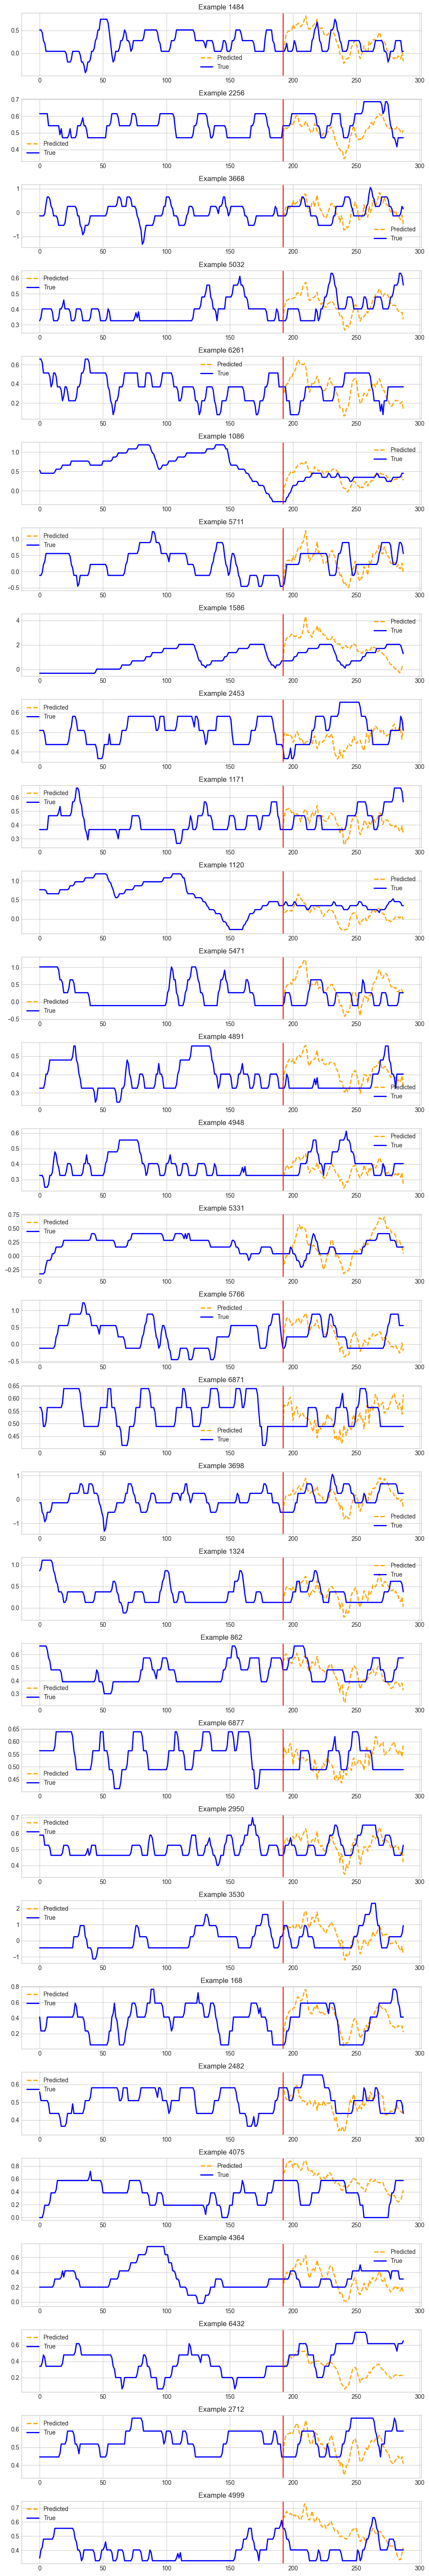

In [229]:
plot_predictions(
    model=finetune_forecast_model,
    dset=test_dataset,
    plot_prefix="test_finetune",
    channel=0,
    num_plots=30
)